<a href="https://colab.research.google.com/github/dsb4k8/Speech-Emotion-Recognition-CS-5530/blob/main/NEWEMOTION_rec_proj_fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Emotion Recognition from Speech

Cleaned and reorganized notebook for the RAVDESS speech emotion project.

## Group Members
- JoshaLynn
- Janil
- Diego
- Tina


## 1. Environment Setup
Install dependencies once per runtime.


In [1]:
!pip install --upgrade pip
!pip -q install gdown librosa soundfile umap-learn


  Using cached pip-26.0.1-py3-none-any.whl.metadata (4.7 kB)
Using cached pip-26.0.1-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 24.3.1
    Uninstalling pip-24.3.1:
      Successfully uninstalled pip-24.3.1


## 2. Imports and Reproducibility
Set all imports and random seeds in one place.


In [2]:
import os
import glob
import math
import random
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import librosa
import librosa.display
import soundfile as sf

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

SEED = 42
np.random.seed(SEED)
random.seed(SEED)


## 3. Download and Extract the Dataset
The notebook expects the RAVDESS speech actor archive from Google Drive.


In [3]:
DATA_ZIP = "actors_speech.zip"
DATA_DIR = "actors_speech"

if not os.path.exists(DATA_ZIP):
    !gdown --fuzzy "https://drive.google.com/file/d/1Oucj9aJ5ngRK5OXuxgxuVY3AfrJ-L00X/view?usp=sharing" -O {DATA_ZIP}

if not os.path.exists(DATA_DIR):
    !unzip -q {DATA_ZIP} -d {DATA_DIR}

print("Dataset directory exists:", os.path.exists(DATA_DIR))
print("Top-level contents:", os.listdir(DATA_DIR)[:10])


Dataset directory exists: True
Top-level contents: ['Actor_16', 'Actor_11', 'Actor_18', 'Actor_20', 'Actor_21', 'Actor_19', 'Actor_10', 'Actor_17', 'Actor_04', 'Actor_03']


## 4. Audio Loading and Preprocessing
We resample to 16 kHz, normalize the waveform, trim leading/trailing silence, and then pad or truncate to a fixed length.


In [4]:
SR = 16_000
TARGET_SEC = 2.5
TARGET_LEN = int(SR * TARGET_SEC)
TRIM_TOP_DB = 30

def load_audio(path: str, sr: int = SR, trim_top_db: int = TRIM_TOP_DB):
    y, sr = librosa.load(path, sr=sr)
    y = librosa.util.normalize(y)
    y, _ = librosa.effects.trim(y, top_db=trim_top_db)
    return y, sr

def fix_length(y: np.ndarray, target_len: int = TARGET_LEN) -> np.ndarray:
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]
    return y.astype(np.float32)


## 5. Build the Ground-Truth Metadata Table
Parse file names into emotion and intensity labels.


In [5]:
EMOTION = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised",
}
INTENSITY = {"01": "normal", "02": "strong"}

def list_files():
    return sorted(glob.glob(f"{DATA_DIR}/**/*.wav", recursive=True))

def parse_filename_labels(path: str) -> dict:
    parts = os.path.splitext(os.path.basename(path))[0].split("-")
    if len(parts) != 7:
        return {"path": path, "parse_ok": False}
    _, _, em_code, int_code, *_ , actor_code = parts
    return {
        "path": path,
        "parse_ok": True,
        "emotion": EMOTION.get(em_code, "unknown"),
        "intensity": INTENSITY.get(int_code, "unknown"),
        "actor_id": int(actor_code),
    }

rows = [parse_filename_labels(p) for p in list_files()]
df = pd.DataFrame(rows)
df_valid = df[df["parse_ok"]].copy()
df_valid = df_valid[df_valid["emotion"].ne("unknown") & df_valid["intensity"].ne("unknown")].copy()
df_valid["label"] = df_valid["emotion"] + "_" + df_valid["intensity"]
df_valid = df_valid.reset_index(drop=True)

df_valid.to_csv("ground_truth_labels.csv", index=False)

print("Total parsed files:", len(df))
print("Valid files:", len(df_valid))
display(df_valid.head())


Total parsed files: 1440
Valid files: 1440


,path,parse_ok,emotion,intensity,actor_id,label
0,actors_speech/Actor_01/03-01-01-01-01-01-01.wav,True,neutral,normal,1,neutral_normal
1,actors_speech/Actor_01/03-01-01-01-01-02-01.wav,True,neutral,normal,1,neutral_normal
2,actors_speech/Actor_01/03-01-01-01-02-01-01.wav,True,neutral,normal,1,neutral_normal
3,actors_speech/Actor_01/03-01-01-01-02-02-01.wav,True,neutral,normal,1,neutral_normal
4,actors_speech/Actor_01/03-01-02-01-01-01-01.wav,True,calm,normal,1,calm_normal


## 6. Quick Sanity Checks


In [6]:
print("Unique emotions:", sorted(df_valid["emotion"].unique()))
print("Unique intensities:", sorted(df_valid["intensity"].unique()))
print("Unique combined labels:", len(df_valid["label"].unique()))
display(df_valid["label"].value_counts().sort_index())


Unique emotions: ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Unique intensities: ['normal', 'strong']
Unique combined labels: 15


label
angry_normal        96
angry_strong        96
calm_normal         96
calm_strong         96
disgust_normal      96
disgust_strong      96
fearful_normal      96
fearful_strong      96
happy_normal        96
happy_strong        96
neutral_normal      96
sad_normal          96
sad_strong          96
surprised_normal    96
surprised_strong    96
Name: count, dtype: int64

## 7. Visualize Preprocessing on One Example


/Users/diegob/PycharmProjects/Speech-Emotion-Recognition-CS-5530/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Raw duration (sec): 3.303
Trimmed duration (sec): 1.376
Fixed duration (sec): 2.5


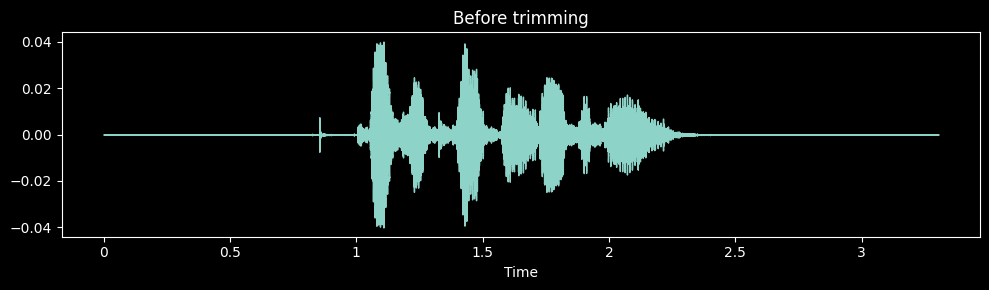

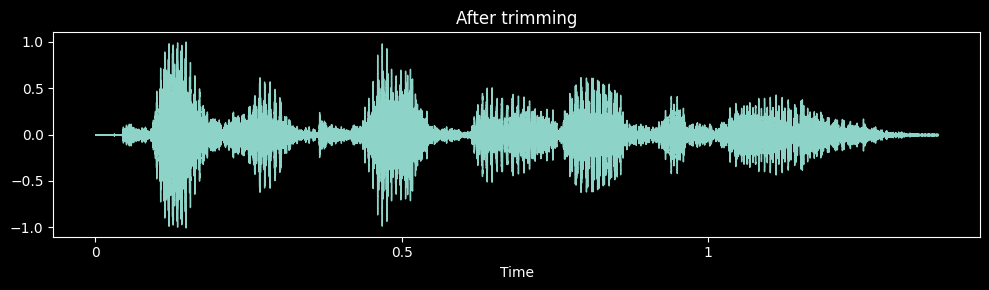

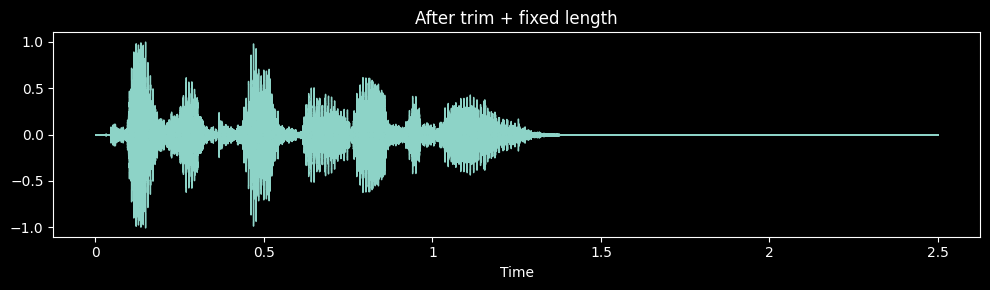

In [7]:
sample_path = df_valid.loc[0, "path"]

y_raw, sr = librosa.load(sample_path, sr=SR)
y_trim, _ = librosa.effects.trim(librosa.util.normalize(y_raw), top_db=TRIM_TOP_DB)
y_fixed = fix_length(y_trim)

print("Raw duration (sec):", round(len(y_raw) / sr, 3))
print("Trimmed duration (sec):", round(len(y_trim) / sr, 3))
print("Fixed duration (sec):", round(len(y_fixed) / sr, 3))

plt.figure(figsize=(10, 3))
librosa.display.waveshow(y_raw, sr=sr)
plt.title("Before trimming")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 3))
librosa.display.waveshow(y_trim, sr=sr)
plt.title("After trimming")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 3))
librosa.display.waveshow(y_fixed, sr=sr)
plt.title("After trim + fixed length")
plt.tight_layout()
plt.show()


## 8. Apply Preprocessing to the Full Dataset
This keeps waveform order aligned with `df_valid`, which avoids the indexing bug from the earlier notebook.


In [8]:
audio_signals = []
for path in df_valid["path"]:
    y, _ = load_audio(path, sr=SR)
    audio_signals.append(y)

X_fixed = np.stack([fix_length(y) for y in audio_signals]).astype(np.float32)

print("Loaded clips:", len(audio_signals))
print("Fixed waveform matrix shape:", X_fixed.shape)


Loaded clips: 1440
Fixed waveform matrix shape: (1440, 40000)


## 9. Exploratory Data Analysis


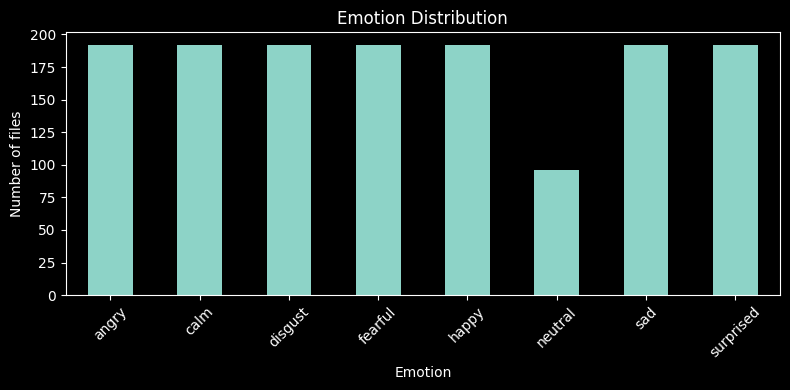

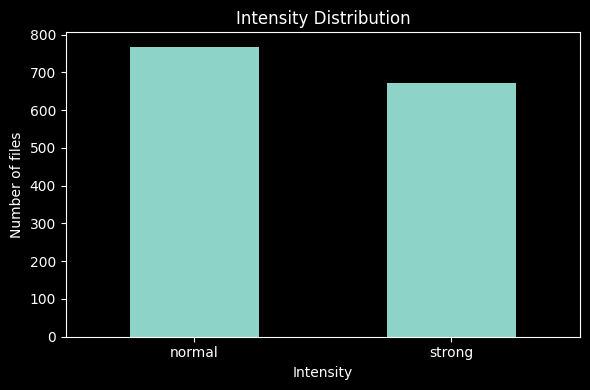

In [9]:
plt.figure(figsize=(8, 4))
df_valid["emotion"].value_counts().sort_index().plot(kind="bar")
plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of files")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
df_valid["intensity"].value_counts().sort_index().plot(kind="bar")
plt.title("Intensity Distribution")
plt.xlabel("Intensity")
plt.ylabel("Number of files")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


,path,emotion,intensity,label
0,actors_speech/Actor_01/03-01-05-01-01-01-01.wav,angry,normal,angry_normal
1,actors_speech/Actor_01/03-01-05-02-01-01-01.wav,angry,strong,angry_strong
2,actors_speech/Actor_01/03-01-02-01-01-01-01.wav,calm,normal,calm_normal
3,actors_speech/Actor_01/03-01-02-02-01-01-01.wav,calm,strong,calm_strong
4,actors_speech/Actor_01/03-01-07-01-01-01-01.wav,disgust,normal,disgust_normal
5,actors_speech/Actor_01/03-01-07-02-01-01-01.wav,disgust,strong,disgust_strong
6,actors_speech/Actor_01/03-01-06-01-01-01-01.wav,fearful,normal,fearful_normal
7,actors_speech/Actor_01/03-01-06-02-01-01-01.wav,fearful,strong,fearful_strong
8,actors_speech/Actor_01/03-01-03-01-01-01-01.wav,happy,normal,happy_normal
9,actors_speech/Actor_01/03-01-03-02-01-01-01.wav,happy,strong,happy_strong


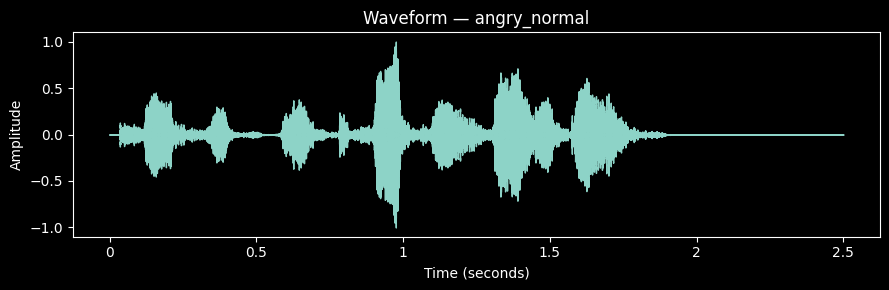

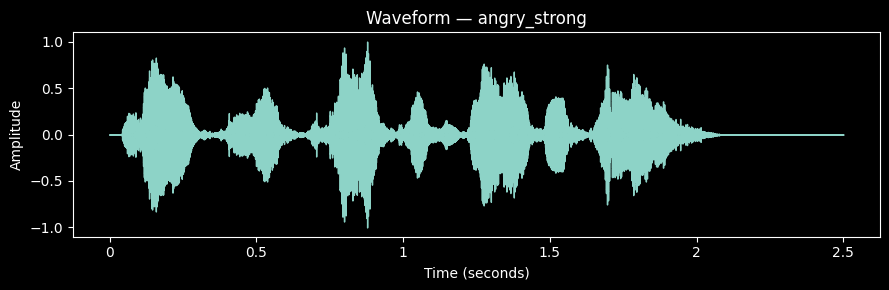

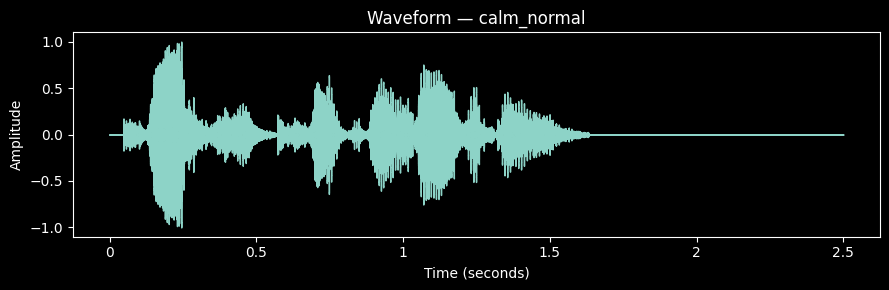

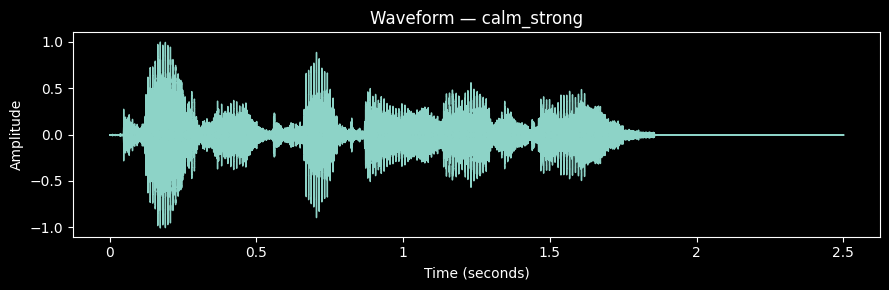

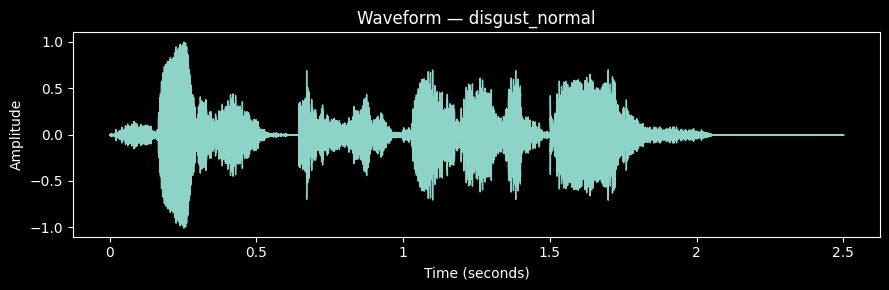

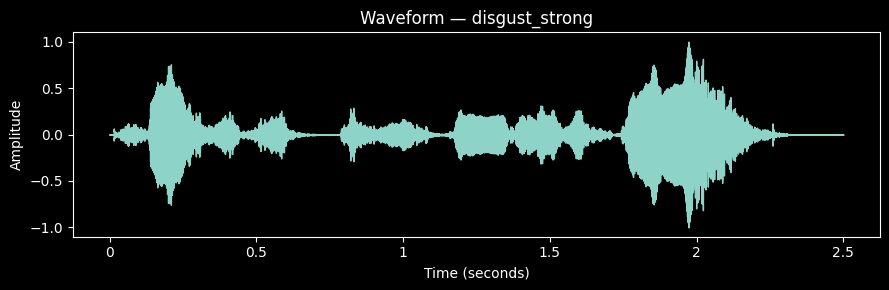

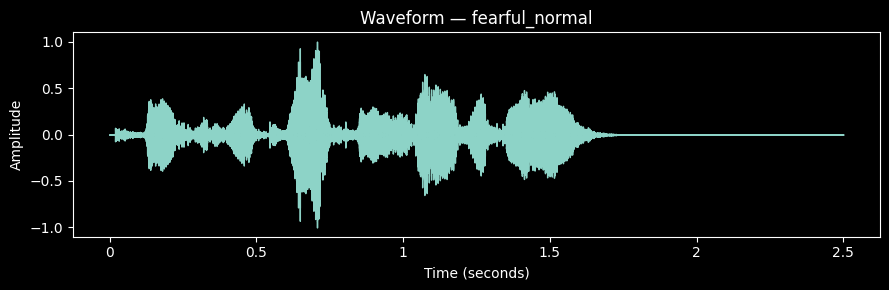

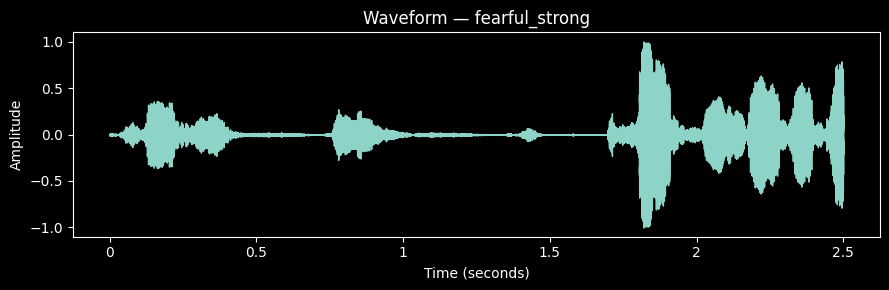

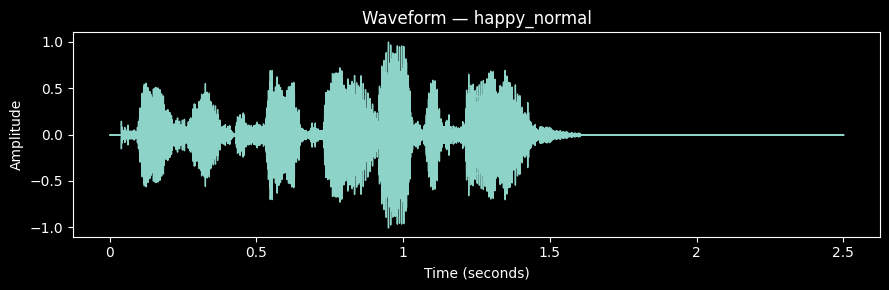

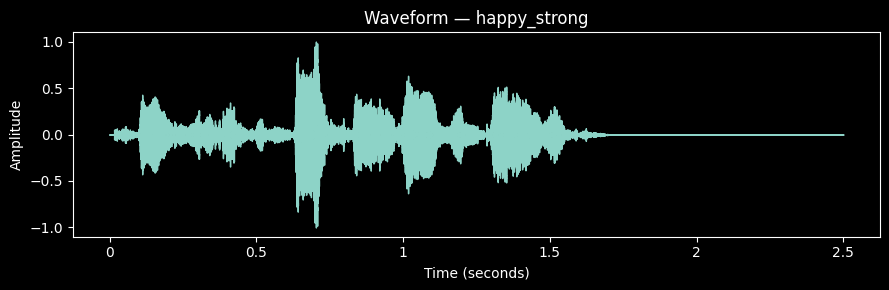

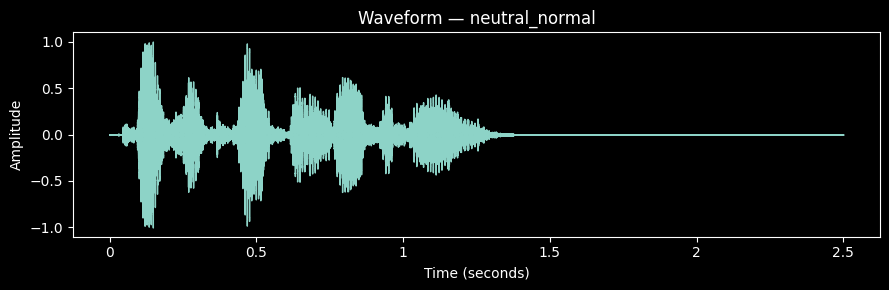

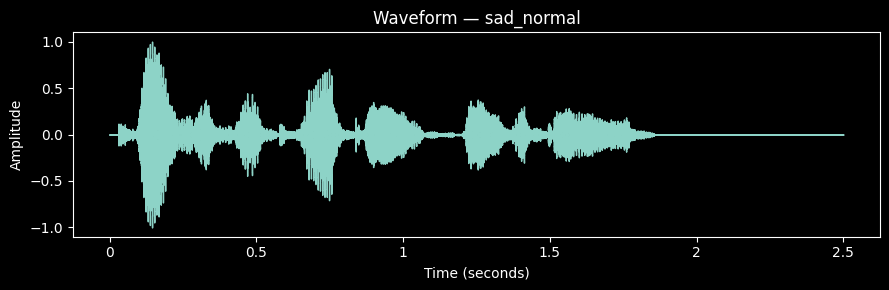

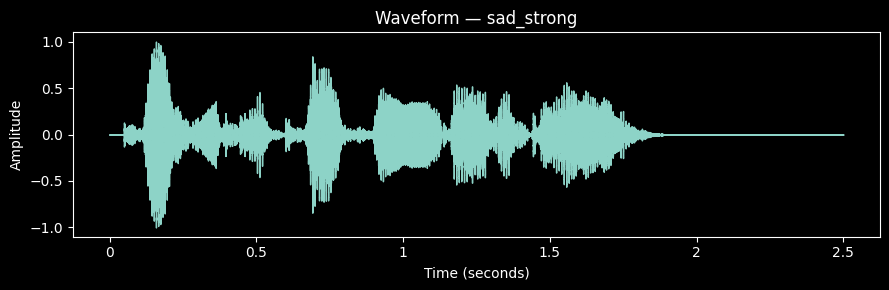

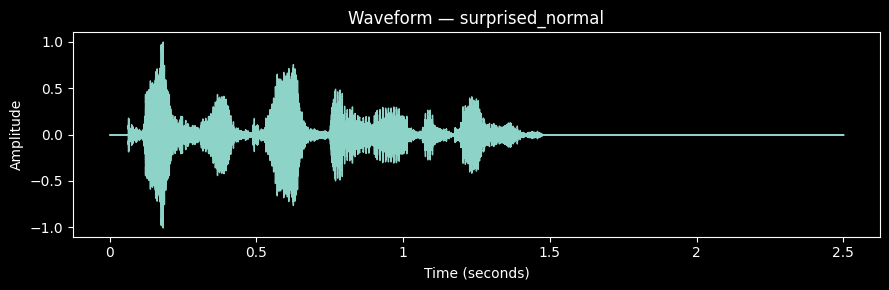

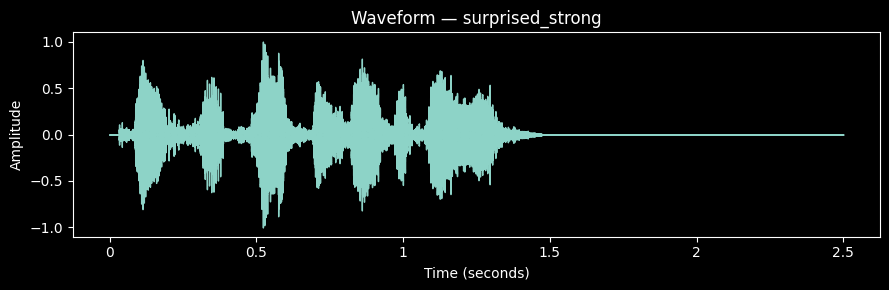

In [10]:
one_per_group = (
    df_valid
    .drop_duplicates(subset=["emotion", "intensity"])
    [["path", "emotion", "intensity"]]
    .sort_values(["emotion", "intensity"])
    .reset_index(drop=True)
)

one_per_group["label"] = one_per_group["emotion"] + "_" + one_per_group["intensity"]
display(one_per_group)

for _, row in one_per_group.iterrows():
    y, sr = load_audio(row["path"], sr=SR)
    y = fix_length(y)
    plt.figure(figsize=(9, 3))
    librosa.display.waveshow(y, sr=sr)
    plt.title(f"Waveform — {row['label']}")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()


## 10. Actor-Based Train / Validation / Test Split
We split by actor to reduce speaker overlap across partitions.


In [11]:
groups = df_valid["actor_id"].to_numpy()

splitter1 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_val_idx, test_idx = next(splitter1.split(df_valid, groups=groups))

train_val_df = df_valid.iloc[train_val_idx].copy().reset_index(drop=False)
test_df = df_valid.iloc[test_idx].copy().reset_index(drop=False)

splitter2 = GroupShuffleSplit(n_splits=1, test_size=0.15 / 0.85, random_state=43)
train_rel_idx, val_rel_idx = next(
    splitter2.split(train_val_df, groups=train_val_df["actor_id"])
)

train_df = train_val_df.iloc[train_rel_idx].copy()
val_df = train_val_df.iloc[val_rel_idx].copy()

split_summary_df = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "num_samples": [len(train_df), len(val_df), len(test_df)],
    "num_actors": [
        train_df["actor_id"].nunique(),
        val_df["actor_id"].nunique(),
        test_df["actor_id"].nunique(),
    ],
    "actors": [
        sorted(train_df["actor_id"].unique().tolist()),
        sorted(val_df["actor_id"].unique().tolist()),
        sorted(test_df["actor_id"].unique().tolist()),
    ],
})
display(split_summary_df)


,split,num_samples,num_actors,actors
0,train,960,16,"[2, 3, 4, 5, 6, 7, 10, 11, 13, 14, 15, 16, 20,..."
1,validation,240,4,"[8, 12, 18, 24]"
2,test,240,4,"[1, 9, 17, 19]"


# Baseline Model: Handcrafted Features + SVC

This section builds a baseline classifier using engineered audio features. All prior steps (data loading, preprocessing, and labels) are shared with the deep learning model.

## 11. Handcrafted Feature Extraction
Define the feature configuration and extraction pipeline in one place.


In [12]:
@dataclass
class FeatureConfig:
    n_fft: int = 1024
    hop_length: int = 256
    n_mfcc: int = 13
    n_mels: int = 40
    fmin: float = 50.0
    fmax: float = 500.0

PROJECT_FEATURE_CFG = FeatureConfig()

def summarize_vector(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=np.float32).reshape(-1)
    if x.size == 0:
        return np.zeros(4, dtype=np.float32)
    return np.array([x.mean(), x.std(), x.min(), x.max()], dtype=np.float32)

def safe_delta(x: np.ndarray) -> np.ndarray:
    if x.shape[-1] < 3:
        return np.zeros_like(x)
    return librosa.feature.delta(x)

def extract_handcrafted_features(y: np.ndarray, sr: int, cfg: FeatureConfig) -> np.ndarray:
    feats = []

    zcr = librosa.feature.zero_crossing_rate(y, frame_length=cfg.n_fft, hop_length=cfg.hop_length)[0]
    rms = librosa.feature.rms(y=y, frame_length=cfg.n_fft, hop_length=cfg.hop_length)[0]
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr, n_fft=cfg.n_fft, hop_length=cfg.hop_length)[0]
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr, n_fft=cfg.n_fft, hop_length=cfg.hop_length)[0]
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, n_fft=cfg.n_fft, hop_length=cfg.hop_length)[0]
    flatness = librosa.feature.spectral_flatness(y=y, n_fft=cfg.n_fft, hop_length=cfg.hop_length)[0]

    for arr in [zcr, rms, centroid, bandwidth, rolloff, flatness]:
        feats.extend(summarize_vector(arr))

    mfcc = librosa.feature.mfcc(
        y=y, sr=sr, n_mfcc=cfg.n_mfcc, n_fft=cfg.n_fft, hop_length=cfg.hop_length
    )
    mfcc_delta = safe_delta(mfcc)

    feats.extend(mfcc.mean(axis=1))
    feats.extend(mfcc.std(axis=1))
    feats.extend(mfcc_delta.mean(axis=1))
    feats.extend(mfcc_delta.std(axis=1))

    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_fft=cfg.n_fft, hop_length=cfg.hop_length, n_mels=cfg.n_mels
    )
    log_mel = librosa.power_to_db(mel + 1e-10)
    log_mel_delta = safe_delta(log_mel)
    log_mel_delta2 = safe_delta(log_mel_delta)

    for arr in [log_mel, log_mel_delta, log_mel_delta2]:
        feats.extend(arr.mean(axis=1))
        feats.extend(arr.std(axis=1))

    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=cfg.n_fft, hop_length=cfg.hop_length)
    feats.extend(chroma.mean(axis=1))
    feats.extend(chroma.std(axis=1))

    pitch = librosa.yin(y, fmin=cfg.fmin, fmax=cfg.fmax, sr=sr, frame_length=cfg.n_fft, hop_length=cfg.hop_length)
    finite_pitch = pitch[np.isfinite(pitch)]
    feats.extend(summarize_vector(finite_pitch))
    voiced_ratio = float(np.mean(np.isfinite(pitch))) if len(pitch) else 0.0
    feats.append(voiced_ratio)

    return np.asarray(feats, dtype=np.float32)

def build_handcrafted_feature_names(cfg: FeatureConfig) -> list[str]:
    names = []
    stat_suffixes = ["mean", "std", "min", "max"]

    for prefix in ["zcr", "rms", "spectral_centroid", "spectral_bandwidth", "spectral_rolloff", "spectral_flatness"]:
        names.extend([f"{prefix}_{suffix}" for suffix in stat_suffixes])

    for i in range(cfg.n_mfcc):
        names.append(f"mfcc_mean_{i+1:02d}")
    for i in range(cfg.n_mfcc):
        names.append(f"mfcc_std_{i+1:02d}")
    for i in range(cfg.n_mfcc):
        names.append(f"mfcc_delta_mean_{i+1:02d}")
    for i in range(cfg.n_mfcc):
        names.append(f"mfcc_delta_std_{i+1:02d}")

    for prefix in [
        "log_mel_mean",
        "log_mel_std",
        "log_mel_delta_mean",
        "log_mel_delta_std",
        "log_mel_delta2_mean",
        "log_mel_delta2_std",
    ]:
        for i in range(cfg.n_mels):
            names.append(f"{prefix}_{i+1:02d}")

    for prefix in ["chroma_mean", "chroma_std"]:
        for i in range(12):
            names.append(f"{prefix}_{i+1:02d}")

    names.extend([f"pitch_{suffix}" for suffix in stat_suffixes])
    names.append("voiced_ratio")
    return names

feature_names = build_handcrafted_feature_names(PROJECT_FEATURE_CFG)
print("Expected feature count:", len(feature_names))


Expected feature count: 345


In [13]:
features = [extract_handcrafted_features(y, SR, PROJECT_FEATURE_CFG) for y in X_fixed]
X_features = np.stack(features).astype(np.float32)

print("Feature matrix shape:", X_features.shape)
print("Matches expected size:", X_features.shape[1] == len(feature_names))


Feature matrix shape: (1440, 345)
Matches expected size: True


## 12. Feature Table
Combine metadata and extracted features into one dataframe.


In [14]:
full_feature_df = pd.concat(
    [
        df_valid[["path", "actor_id", "emotion", "intensity", "label"]].reset_index(drop=True),
        pd.DataFrame(X_features, columns=feature_names),
    ],
    axis=1,
)

print("Full feature dataframe shape: ", full_feature_df.shape)
display(full_feature_df.head())


Full feature dataframe shape:  (1440, 350)


,path,actor_id,emotion,intensity,label,zcr_mean,zcr_std,zcr_min,zcr_max,rms_mean,...,chroma_std_08,chroma_std_09,chroma_std_10,chroma_std_11,chroma_std_12,pitch_mean,pitch_std,pitch_min,pitch_max,voiced_ratio
0,actors_speech/Actor_01/03-01-01-01-01-01-01.wav,1,neutral,normal,neutral_normal,0.060466,0.080883,0.0,0.351562,0.070988,...,0.307759,0.305904,0.335028,0.319955,0.299494,290.873962,192.751526,50.166874,500.0,1.0
1,actors_speech/Actor_01/03-01-01-01-01-02-01.wav,1,neutral,normal,neutral_normal,0.055117,0.076369,0.0,0.361328,0.064666,...,0.297376,0.311229,0.336336,0.311430,0.291903,289.887543,189.482315,54.963158,500.0,1.0
2,actors_speech/Actor_01/03-01-01-01-02-01-01.wav,1,neutral,normal,neutral_normal,0.068509,0.118158,0.0,0.604492,0.060762,...,0.286486,0.313390,0.344046,0.280882,0.275171,294.668030,193.617554,57.535954,500.0,1.0
3,actors_speech/Actor_01/03-01-01-01-02-02-01.wav,1,neutral,normal,neutral_normal,0.064304,0.112940,0.0,0.570312,0.051672,...,0.339717,0.329279,0.293120,0.299377,0.259609,299.488739,194.374725,52.319328,500.0,1.0
4,actors_speech/Actor_01/03-01-02-01-01-01-01.wav,1,calm,normal,calm_normal,0.088096,0.128302,0.0,0.625000,0.086976,...,0.327242,0.331221,0.353490,0.356731,0.302696,256.746979,183.989365,50.152962,500.0,1.0


## 13. Split the Feature Matrix
Because `df_valid` was reset before preprocessing, these indices now align correctly with `X_features`.


In [15]:
X_train = X_features[train_df["index"].to_numpy()]
X_val = X_features[val_df["index"].to_numpy()]
X_test = X_features[test_df["index"].to_numpy()]

y_train = train_df["emotion"].to_numpy()
y_val = val_df["emotion"].to_numpy()
y_test = test_df["emotion"].to_numpy()

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val:", X_val.shape, "| y_val:", y_val.shape)
print("X_test:", X_test.shape, "| y_test:", y_test.shape)


X_train: (960, 345) | y_train: (960,)
X_val: (240, 345) | y_val: (240,)
X_test: (240, 345) | y_test: (240,)


## 14. Interpretable Feature Visualizations


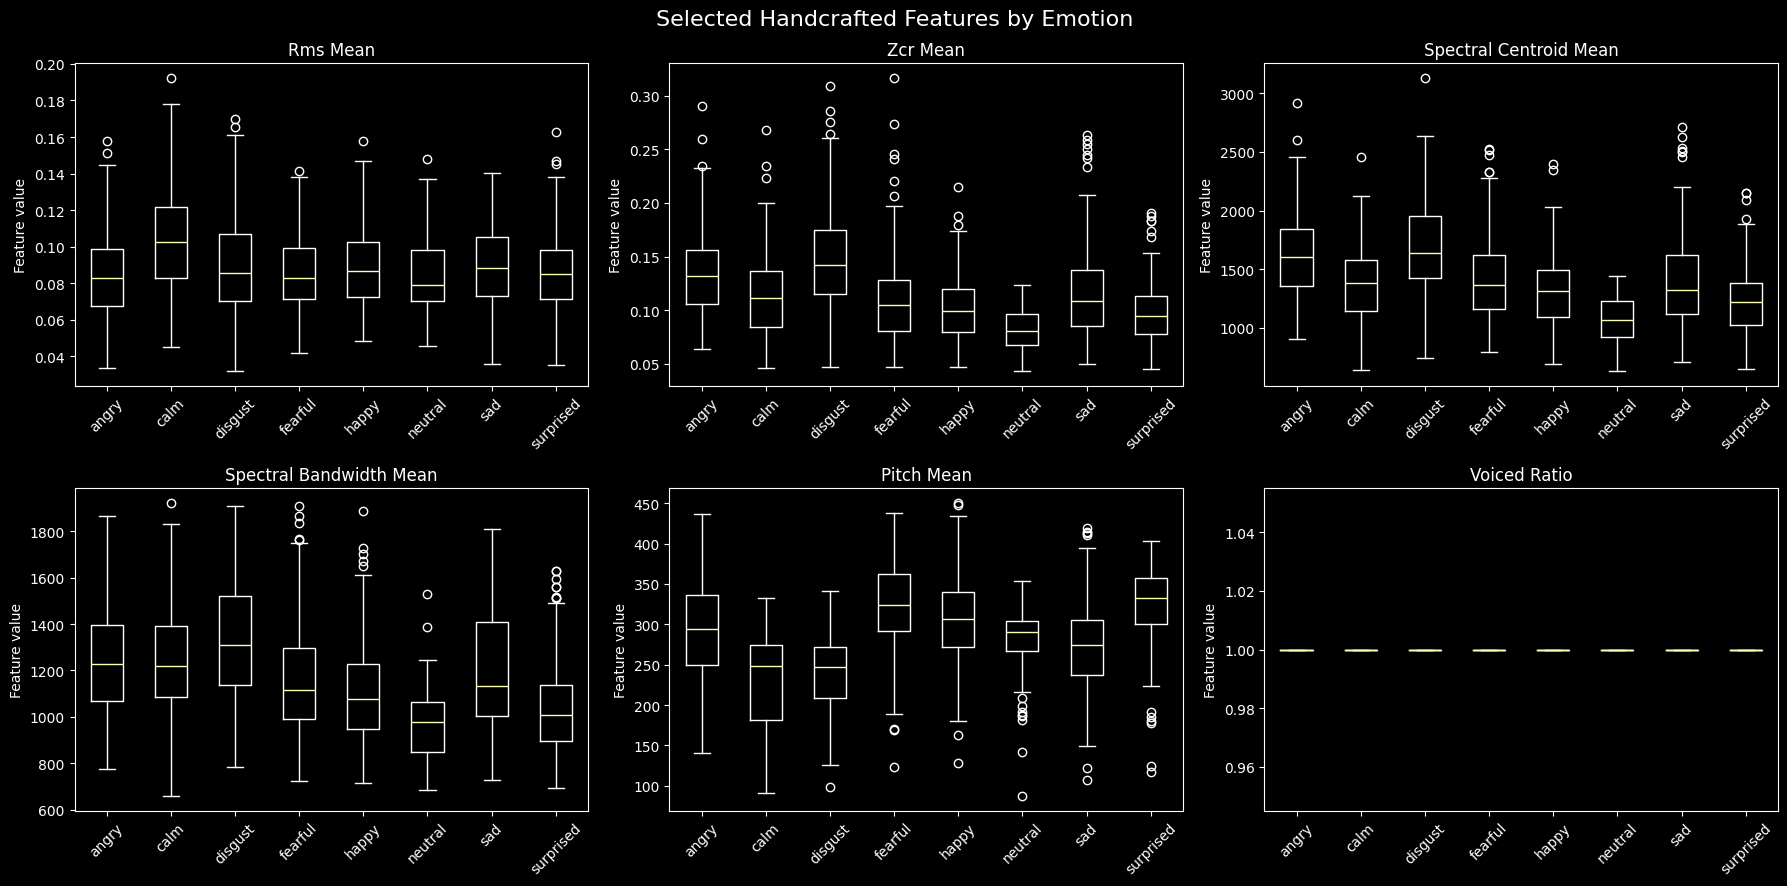

In [16]:
selected_feature_columns = [
    "rms_mean",
    "zcr_mean",
    "spectral_centroid_mean",
    "spectral_bandwidth_mean",
    "pitch_mean",
    "voiced_ratio",
]

emotion_order = sorted(full_feature_df["emotion"].unique())

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, column in zip(axes.ravel(), selected_feature_columns):
    grouped_values = [
        full_feature_df.loc[full_feature_df["emotion"] == emotion, column].values
        for emotion in emotion_order
    ]
    ax.boxplot(grouped_values, tick_labels=emotion_order)
    ax.set_title(column.replace("_", " ").title())
    ax.tick_params(axis="x", rotation=45)
    ax.set_ylabel("Feature value")

plt.suptitle("Selected Handcrafted Features by Emotion", fontsize=16)
plt.tight_layout()
plt.show()


## 15. Standardize the Feature Matrix


In [17]:
feature_matrix = full_feature_df[feature_names].to_numpy(dtype=np.float32)
emotion_labels = full_feature_df["emotion"].to_numpy()
intensity_labels = full_feature_df["intensity"].to_numpy()

feature_scaler = StandardScaler()
feature_matrix_scaled = feature_scaler.fit_transform(feature_matrix)

print("Scaled feature matrix shape:", feature_matrix_scaled.shape)


Scaled feature matrix shape: (1440, 345)


## 16. LDA Projection


LDA (Linear Discriminant Analysis) projects the feature space into a lower-dimensional representation that maximizes separation between emotion classes. This allows us to visualize how well the engineered features distinguish different emotions.

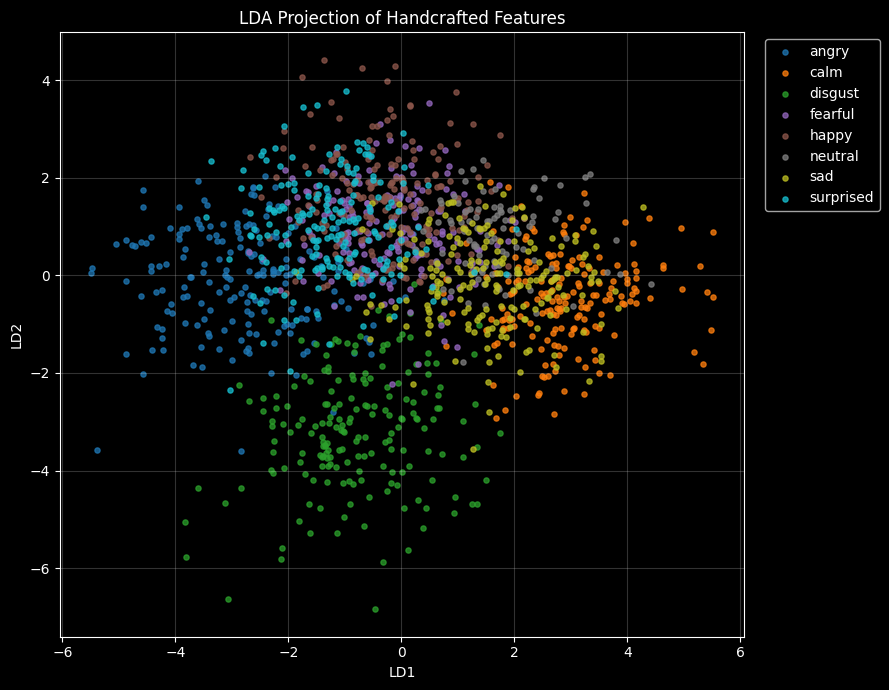

In [18]:
lda = LinearDiscriminantAnalysis(n_components=2)
lda_coords = lda.fit_transform(feature_matrix_scaled, emotion_labels)

lda_df = full_feature_df[["emotion", "intensity", "actor_id"]].copy()
lda_df["x"] = lda_coords[:, 0]
lda_df["y"] = lda_coords[:, 1]

fig, ax = plt.subplots(figsize=(9, 7))
emotion_order = sorted(lda_df["emotion"].unique())
colors = plt.cm.tab10(np.linspace(0, 1, len(emotion_order)))

for color, emotion in zip(colors, emotion_order):
    subset = lda_df[lda_df["emotion"] == emotion]
    ax.scatter(subset["x"], subset["y"], label=emotion, alpha=0.75, s=14, color=color)

ax.set_title("LDA Projection of Handcrafted Features")
ax.set_xlabel("LD1")
ax.set_ylabel("LD2")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


KMeans clustering is applied to the LDA-projected data to compare natural groupings with the true emotion labels.

## 17. LDA + KMeans Clustering


Fit KMeans and prepare labels

In [19]:
kmeans_2d = KMeans(n_clusters=len(emotion_order), random_state=SEED, n_init="auto")
cluster_ids = kmeans_2d.fit_predict(lda_coords)
centers = kmeans_2d.cluster_centers_

lda_cluster_df = lda_df.copy()
lda_cluster_df["cluster"] = cluster_ids.astype(str)

cluster_order = sorted(lda_cluster_df["cluster"].unique(), key=int)
cluster_colors = plt.cm.Set2(np.linspace(0, 1, len(cluster_order)))

Plot true emotion labels

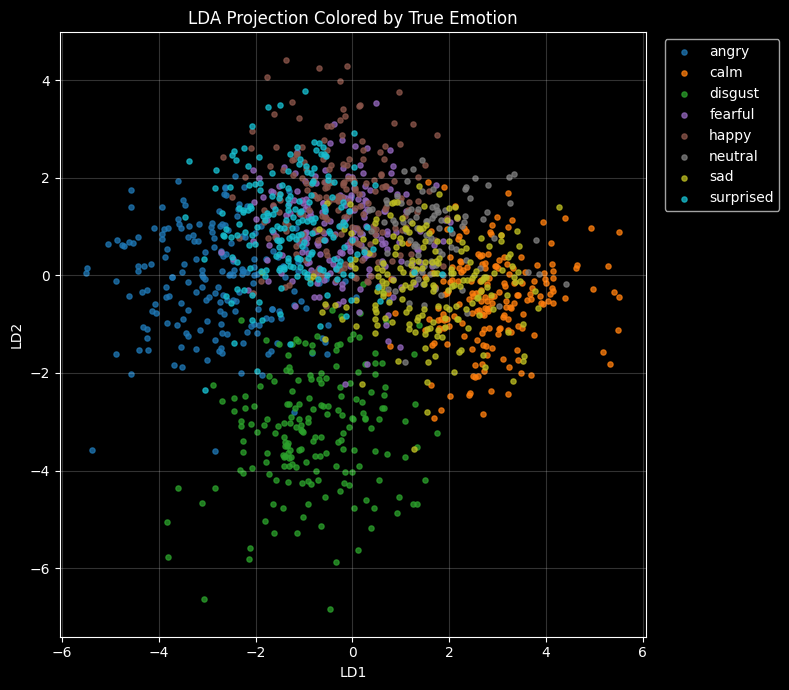

In [20]:
plt.figure(figsize=(8, 7))

for color, emotion in zip(colors, emotion_order):
    subset = lda_cluster_df[lda_cluster_df["emotion"] == emotion]
    plt.scatter(subset["x"], subset["y"], label=emotion, alpha=0.75, s=14, color=color)

plt.title("LDA Projection Colored by True Emotion")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.grid(alpha=0.2)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

Plot KMeans clusters

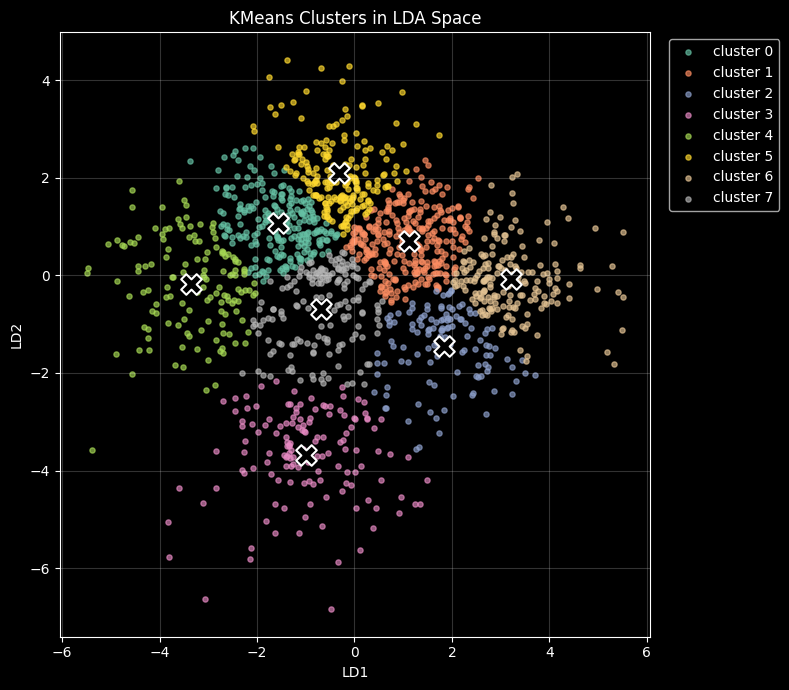

In [21]:
plt.figure(figsize=(8, 7))

for i, cluster in enumerate(cluster_order):
    subset = lda_cluster_df[lda_cluster_df["cluster"] == cluster]
    plt.scatter(subset["x"], subset["y"], label=f"cluster {cluster}", alpha=0.65, s=14, color=cluster_colors[i])

    cx, cy = centers[i]
    plt.scatter(cx, cy, marker="X", s=220, color="black", edgecolor="white", linewidth=1.5)

plt.title("KMeans Clusters in LDA Space")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.grid(alpha=0.2)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

While KMeans clustering produces visually well-separated groups in LDA space, these clusters do not perfectly align with the true emotion labels. This suggests that the engineered features capture underlying acoustic similarities (such as intensity or pitch) that do not fully correspond to discrete emotion categories.

# Data Augmentation Example

This example compares an original waveform with an augmented version produced by the training pipeline. The current notebook keeps additive noise and time shift enabled. Cross-speaker mixing is disabled.



This section demonstrates a simple augmentation pass on one waveform using additive noise and time shift. It is included to illustrate how small input variations can improve robustness.

In [22]:
def augment_waveform(wave, rng, noise_level=0.005, max_shift=0.1):
    # Add Gaussian noise
    noise = rng.normal(0, noise_level, size=wave.shape)
    wave = wave + noise

    # Time shift (circular)
    shift = int(len(wave) * rng.uniform(-max_shift, max_shift))
    wave = np.roll(wave, shift)

    return wave

In [23]:
# Safety checks (run first)
assert "df_valid" in globals(), "Run metadata section first"
assert "path" in df_valid.columns
assert "emotion" in df_valid.columns

rng = np.random.default_rng(42)

# Select example
example_emotion = sorted(df_valid["emotion"].unique())[0]
example_record = (
    df_valid[df_valid["emotion"] == example_emotion]
    .sort_values(["actor_id"])
    .iloc[0]
)

# Load audio
example_path = example_record["path"]
anchor_wave, _ = load_audio(example_path, sr=SR)

# Augment
augmented_wave = augment_waveform(anchor_wave, rng)

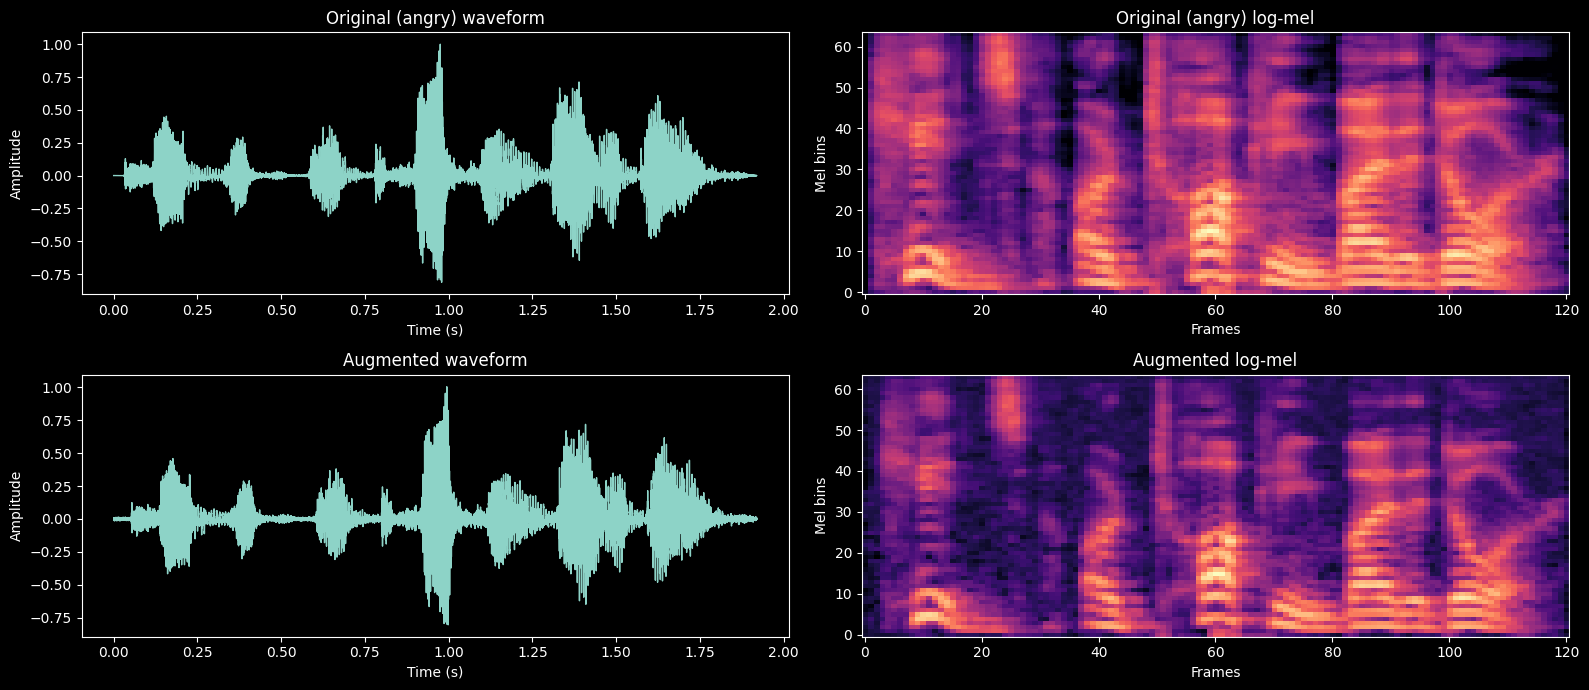

In [24]:
def plot_wave_and_mel(ax_wave, ax_mel, signal, title, sr=16000):
    time_axis = np.arange(len(signal)) / sr
    ax_wave.plot(time_axis, signal, linewidth=1.0)
    ax_wave.set_title(f"{title} waveform")
    ax_wave.set_xlabel("Time (s)")
    ax_wave.set_ylabel("Amplitude")

    mel = librosa.feature.melspectrogram(
        y=signal, sr=sr, n_fft=1024, hop_length=256, n_mels=64
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    ax_mel.imshow(mel_db, origin="lower", aspect="auto", cmap="magma")
    ax_mel.set_title(f"{title} log-mel")
    ax_mel.set_xlabel("Frames")
    ax_mel.set_ylabel("Mel bins")

fig, axes = plt.subplots(2, 2, figsize=(16, 7))
plot_wave_and_mel(axes[0, 0], axes[0, 1], anchor_wave, f"Original ({example_emotion})", SR)
plot_wave_and_mel(axes[1, 0], axes[1, 1], augmented_wave, "Augmented", SR)
plt.tight_layout()
plt.show()

In [25]:
from IPython.display import Audio, display, Markdown

print("Emotion example:", example_emotion)
print("Augmentation shown: noise + time shift")

display(Markdown(f"### Original ({example_emotion})"))
display(Audio(anchor_wave, rate=SR))

display(Markdown("### Augmented"))
display(Audio(augmented_wave, rate=SR))

Emotion example: angry
Augmentation shown: noise + time shift


### Original (angry)

### Augmented

Why This Matters

The augmentation pipeline improves robustness by exposing the model to variation in:

- background noise,
- timing and alignment of speech,
- recording conditions.

This helps the model generalize better across different speakers and environments rather than overfitting to clean, fixed recordings.

Including this visualization also strengthens the presentation by linking the raw audio transformations to their impact on model performance.

#BaseLine Model

Hyperparameter Tuning (Summary)

A grid search over C ∈ {0.1, 1, 10} and gamma ∈ {"scale", 0.01, 0.001} was performed using 3-fold cross-validation.

Best parameters:
- C = 10  
- gamma = 0.001  

These values are used below for the final baseline model.

In [26]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Labels
y_train = train_df["emotion"].to_numpy()
y_val = val_df["emotion"].to_numpy()
y_test = test_df["emotion"].to_numpy()

# Tuned SVM
best_model = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf", class_weight="balanced", C=10, gamma=0.001)
)

best_model.fit(X_train, y_train)

# Validation predictions
val_preds = best_model.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, val_preds))
print(classification_report(y_val, val_preds))

Validation Accuracy: 0.5625
              precision    recall  f1-score   support

       angry       0.61      0.69      0.65        32
        calm       0.59      0.91      0.72        32
     disgust       0.60      0.56      0.58        32
     fearful       0.52      0.34      0.42        32
       happy       0.51      0.62      0.56        32
     neutral       0.67      0.50      0.57        16
         sad       0.41      0.41      0.41        32
   surprised       0.67      0.44      0.53        32

    accuracy                           0.56       240
   macro avg       0.57      0.56      0.55       240
weighted avg       0.57      0.56      0.55       240



In [27]:
# Test predictions
test_preds = best_model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, test_preds))
print(classification_report(y_test, test_preds))

Test Accuracy: 0.4125
              precision    recall  f1-score   support

       angry       0.83      0.59      0.69        32
        calm       0.51      0.56      0.54        32
     disgust       0.48      0.38      0.42        32
     fearful       0.37      0.44      0.40        32
       happy       0.45      0.31      0.37        32
     neutral       0.19      0.19      0.19        16
         sad       0.27      0.62      0.38        32
   surprised       0.43      0.09      0.15        32

    accuracy                           0.41       240
   macro avg       0.44      0.40      0.39       240
weighted avg       0.46      0.41      0.41       240



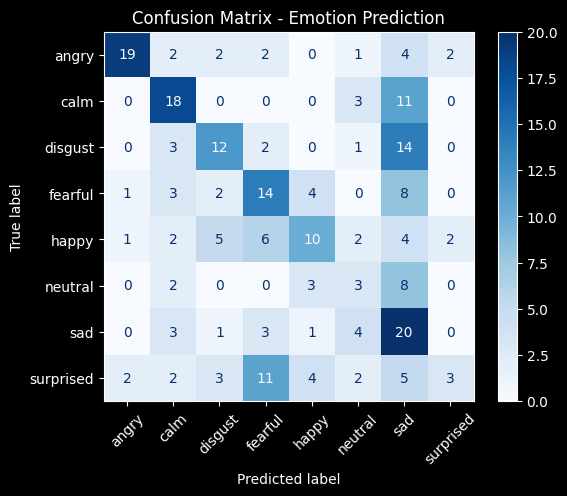

In [28]:
# Confusion matrix
cm = confusion_matrix(y_test, test_preds, labels=sorted(np.unique(y_test)))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=sorted(np.unique(y_test))
)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - Emotion Prediction")
plt.show()

**The baseline model provides a feature-engineered reference point. We now extend this approach by building a hybrid deep learning model that combines transformer-based representations from raw audio with handcrafted acoustic features.**

# Final Model: Hybrid Deep Learning Model

This model combines transformer-based representations from raw audio with handcrafted acoustic features.
The transformer captures complex temporal speech patterns, while the engineered features provide interpretable
descriptors such as pitch, energy, and spectral characteristics.

This hybrid approach allows the model to leverage both learned and domain-specific features.

#Training Utilities


These helper functions handle device selection, class imbalance, and loss computation.
Focal loss is used to improve performance on difficult or underrepresented classes.

In [29]:
# Deep learning imports and shared utilities
import copy
import random
from dataclasses import dataclass
from pathlib import Path
from types import SimpleNamespace
from typing import Dict, List, Tuple

import numpy as np
import torch
from torch import nn
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from transformers import AutoFeatureExtractor, AutoModel
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.utils.class_weight import compute_class_weight

def resolve_notebook_device(device_name="auto"):
    if device_name == "cpu":
        return torch.device("cpu")
    if device_name == "cuda":
        if not torch.cuda.is_available():
            raise RuntimeError("CUDA requested but unavailable.")
        return torch.device("cuda")
    if device_name == "mps":
        if not torch.backends.mps.is_available():
            raise RuntimeError("MPS requested but unavailable.")
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

def set_global_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def compute_balanced_weights(num_classes, y):
    weights = compute_class_weight("balanced", classes=np.unique(y), y=y)
    out = np.ones(num_classes, dtype=np.float32)
    for cls, w in zip(np.unique(y), weights):
        out[int(cls)] = w
    return out

class WeightedFocalLoss(nn.Module):
    def __init__(self, class_weights=None, gamma=2.0):
        super().__init__()
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(weight=class_weights, reduction="none")

    def forward(self, logits, targets):
        ce = self.ce(logits, targets)
        pt = torch.softmax(logits, dim=-1).gather(1, targets.unsqueeze(1)).squeeze(1)
        return ((1 - pt) ** self.gamma * ce).mean()

class MultiTaskLoss(nn.Module):
    def __init__(self, emotion_loss, intensity_loss, intensity_weight=0.5):
        super().__init__()
        self.emotion_loss = emotion_loss
        self.intensity_loss = intensity_loss
        self.intensity_weight = intensity_weight

    def forward(self, emotion_logits, intensity_logits, emotion_targets, intensity_targets):
        emotion_term = self.emotion_loss(emotion_logits, emotion_targets)
        intensity_term = self.intensity_loss(intensity_logits, intensity_targets)
        total = emotion_term + self.intensity_weight * intensity_term
        return total, emotion_term.detach(), intensity_term.detach()

ModuleNotFoundError: No module named 'torch'

In [ ]:
# Seed and device helpers are defined in the import cell above.

#Model Configuration and Training Setup

This section defines the configuration for the hybrid deep learning model, including audio settings, augmentation behavior, label mappings, and training hyperparameters.

In [ ]:
FULL_EMOTION_LABELS = [
    "neutral",
    "calm",
    "happy",
    "sad",
    "angry",
    "fearful",
    "disgust",
    "surprised",
]

INTENSITY_LABELS = [
    "normal",
    "strong",
]

In [ ]:
@dataclass
class AudioConfig:
    sample_rate: int = 16000
    duration_seconds: float = 2.5

@dataclass
class AugmentConfig:
    pitch_prob: float = 0.0
    stretch_prob: float = 0.0
    gain_prob: float = 0.0
    speaker_mix_prob: float = 0.0
    speaker_mix_alpha_min: float = 0.35
    speaker_mix_alpha_max: float = 0.65

In [ ]:
NOTEBOOK_OUTPUT_DIR = Path("artifacts_notebook_run")
NOTEBOOK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Audio / feature / augmentation configs
NOTEBOOK_CFG = AudioConfig(sample_rate=16000, duration_seconds=2.5)
NOTEBOOK_FEATURE_CFG = FeatureConfig()
NOTEBOOK_AUG_CFG = AugmentConfig(
    pitch_prob=0.0,
    stretch_prob=0.0,
    gain_prob=0.0,
    speaker_mix_prob=0.0,
    speaker_mix_alpha_min=0.35,
    speaker_mix_alpha_max=0.65,
)

# Labels and model
NOTEBOOK_MODEL_NAME = "superb/hubert-base-superb-er"
NOTEBOOK_EMOTION_LABELS = list(FULL_EMOTION_LABELS)
NOTEBOOK_INTENSITY_LABELS = list(INTENSITY_LABELS)
NOTEBOOK_EMOTION_TO_INDEX = {label: idx for idx, label in enumerate(NOTEBOOK_EMOTION_LABELS)}
NOTEBOOK_INTENSITY_TO_INDEX = {label: idx for idx, label in enumerate(NOTEBOOK_INTENSITY_LABELS)}

# Training hyperparameters
NOTEBOOK_EPOCHS = 25
NOTEBOOK_BATCH_SIZE = 8
NOTEBOOK_PATIENCE = 5
NOTEBOOK_LEARNING_RATE = 1.5e-5
NOTEBOOK_WEIGHT_DECAY = 0.01
NOTEBOOK_WARMUP_RATIO = 0.10
NOTEBOOK_AUGMENT_COPIES = 0
NOTEBOOK_FEATURE_STATS_MAX_RECORDS = 600
NOTEBOOK_FREEZE_FEATURE_ENCODER_EPOCHS = 1
NOTEBOOK_UNFREEZE_LAST_N_LAYERS = 2
NOTEBOOK_FOCAL_GAMMA = 2.0
NOTEBOOK_INTENSITY_LOSS_WEIGHT = 0.5
NOTEBOOK_INTENSITY_METRIC_WEIGHT = 0.5
NOTEBOOK_LABEL_SMOOTHING = 0.05
NOTEBOOK_INTENSITY_LABEL_SMOOTHING = 0.02
NOTEBOOK_HEAD_DROPOUT = 0.2
NOTEBOOK_AUX_HIDDEN_DIM = 128
NOTEBOOK_GRAD_CLIP = 1.0
NOTEBOOK_NUM_WORKERS = 0

# Reproducibility / device
NOTEBOOK_DEVICE = resolve_notebook_device("auto")
NOTEBOOK_SEED = 42
set_global_seed(NOTEBOOK_SEED)

print("Notebook artifacts dir:", NOTEBOOK_OUTPUT_DIR.resolve())
print("Using device:", NOTEBOOK_DEVICE)

#Hybrid Dataset and Augmentation

The dataset class loads raw audio waveforms and optionally applies augmentation during training.
It also extracts handcrafted features, which are included as auxiliary inputs to the model.

Each training sample may include both the original waveform and augmented versions, improving robustness.

In [ ]:
class EmotionDataset(Dataset):
    def __init__(
        self,
        records,
        cfg,
        feature_cfg,
        emotion_map,
        intensity_map,
        use_features=True,
        feature_mean=None,
        feature_std=None,
    ):
        self.records = records
        self.cfg = cfg
        self.feature_cfg = feature_cfg
        self.emotion_map = emotion_map
        self.intensity_map = intensity_map
        self.use_features = use_features
        self.feature_mean = feature_mean
        self.feature_std = feature_std

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        record = self.records[idx]
        waveform = load_waveform(record.path, self.cfg)

        if self.use_features:
            feats = extract_handcrafted_features(waveform, self.cfg.sample_rate, self.feature_cfg)
            if self.feature_mean is not None and self.feature_std is not None:
                feats = (feats - self.feature_mean) / self.feature_std
            feats = feats.astype(np.float32)
        else:
            feats = None

        return {
            "waveform": waveform,
            "emotion_label": self.emotion_map[record.ravdess_emotion],
            "intensity_label": self.intensity_map[record.intensity_label],
            "features": feats,
        }

# Dataloader and Feature Encoding

The collator prepares batches by padding waveforms and converting them into model-ready inputs using a pretrained feature extractor.

In [ ]:
class Collator:
    def __init__(self, extractor, sr):
        self.extractor = extractor
        self.sr = sr

    def __call__(self, batch):
        waveforms = [b["waveform"] for b in batch]
        emotion_labels = torch.tensor([b["emotion_label"] for b in batch], dtype=torch.long)
        intensity_labels = torch.tensor([b["intensity_label"] for b in batch], dtype=torch.long)

        encoded = self.extractor(
            waveforms,
            sampling_rate=self.sr,
            return_tensors="pt",
            padding=True,
        )
        encoded["emotion_labels"] = emotion_labels
        encoded["intensity_labels"] = intensity_labels

        if batch[0]["features"] is not None:
            encoded["aux_features"] = torch.tensor(
                np.stack([b["features"] for b in batch]),
                dtype=torch.float32,
            )

        return encoded

# Handcrafted Feature Normalization

Handcrafted features are normalized using statistics computed from the training set to ensure consistent scaling.

In [ ]:
def compute_feature_stats(records, cfg, feature_cfg):
    feats = []
    for r in records:
        y = load_waveform(r.path, cfg)
        feats.append(extract_handcrafted_features(y, cfg.sample_rate, feature_cfg))
    feats = np.stack(feats)
    return feats.mean(0), feats.std(0) + 1e-6

# Dataset Preparation and Feature Statistics

In [ ]:
def df_to_records(df):
    return [
        SimpleNamespace(
            path=row["path"],
            ravdess_emotion=row["emotion"],
            intensity_label=row["intensity"],
            actor_id=int(row["actor_id"]),
        )
        for _, row in df.iterrows()
    ]

def load_waveform(path, cfg, random_crop=False):
    y, _ = load_audio(path, sr=cfg.sample_rate)
    return y

# Reuse the same split from the baseline model
notebook_train_records = df_to_records(train_df)
notebook_val_records = df_to_records(val_df)
notebook_test_records = df_to_records(test_df)

print(
    f"Split sizes | train={len(notebook_train_records)} "
    f"val={len(notebook_val_records)} "
    f"test={len(notebook_test_records)}"
)

# Compute handcrafted feature normalization stats from the training split only
notebook_feature_mean, notebook_feature_std = compute_feature_stats(
    notebook_train_records,
    cfg=NOTEBOOK_CFG,
    feature_cfg=NOTEBOOK_FEATURE_CFG,
)

notebook_aux_feature_dim = int(notebook_feature_mean.shape[0])
print("Handcrafted feature dimension:", notebook_aux_feature_dim)

## Model Architecture (Hybrid Transformer + Features)

In [ ]:
def _infer_hidden_size(config):
    for attr in ["hidden_size", "classifier_proj_size"]:
        if hasattr(config, attr):
            return int(getattr(config, attr))
    raise ValueError("Could not infer hidden size from backbone config.")

class MultiTaskEmotionModel(nn.Module):
    def __init__(
        self,
        backbone_name_or_path: str,
        num_emotions: int,
        num_intensity: int,
        head_dropout: float = 0.2,
        use_handcrafted_features: bool = False,
        aux_feature_dim: int = 0,
        aux_hidden_dim: int = 128,
    ) -> None:
        super().__init__()
        self.backbone = AutoModel.from_pretrained(backbone_name_or_path)
        hidden_size = _infer_hidden_size(self.backbone.config)

        self.use_handcrafted_features = bool(use_handcrafted_features and aux_feature_dim > 0)
        self.aux_feature_dim = int(aux_feature_dim)

        if self.use_handcrafted_features:
            self.aux_norm = nn.LayerNorm(aux_feature_dim)
            self.aux_mlp = nn.Sequential(
                nn.Linear(aux_feature_dim, aux_hidden_dim),
                nn.GELU(),
                nn.Dropout(head_dropout),
            )
            fused_dim = hidden_size + aux_hidden_dim
        else:
            self.aux_norm = None
            self.aux_mlp = None
            fused_dim = hidden_size

        self.dropout = nn.Dropout(head_dropout)
        self.emotion_head = nn.Linear(fused_dim, num_emotions)
        self.intensity_head = nn.Linear(fused_dim, num_intensity)

    @staticmethod
    def masked_mean_pool(last_hidden_state: torch.Tensor, attention_mask: torch.Tensor | None) -> torch.Tensor:
        if attention_mask is None:
            return last_hidden_state.mean(dim=1)

        mask = attention_mask.unsqueeze(-1).to(dtype=last_hidden_state.dtype)
        summed = (last_hidden_state * mask).sum(dim=1)
        counts = mask.sum(dim=1).clamp(min=1.0)
        return summed / counts

    def _prepare_aux_features(self, pooled: torch.Tensor, aux_features: torch.Tensor | None) -> torch.Tensor:
        if not self.use_handcrafted_features:
            return pooled

        if aux_features is None:
            aux_features = torch.zeros(
                pooled.size(0), self.aux_feature_dim, device=pooled.device, dtype=pooled.dtype
            )

        aux_features = aux_features.to(device=pooled.device, dtype=pooled.dtype)
        aux = self.aux_mlp(self.aux_norm(aux_features))
        return torch.cat([pooled, aux], dim=-1)

    def forward(
        self,
        input_values: torch.Tensor,
        attention_mask: torch.Tensor | None = None,
        aux_features: torch.Tensor | None = None,
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        outputs = self.backbone(
            input_values=input_values,
            attention_mask=attention_mask,
            return_dict=True,
        )

        feature_mask = None
        if attention_mask is not None:
            if hasattr(self.backbone, "_get_feature_vector_attention_mask"):
                feature_mask = self.backbone._get_feature_vector_attention_mask(
                    outputs.last_hidden_state.shape[1],
                    attention_mask,
                )
            else:
                feature_mask = attention_mask[:, :outputs.last_hidden_state.shape[1]]

        pooled = self.masked_mean_pool(outputs.last_hidden_state, feature_mask)
        fused = self._prepare_aux_features(pooled, aux_features)
        fused = self.dropout(fused)

        emotion_logits = self.emotion_head(fused)
        intensity_logits = self.intensity_head(fused)
        return emotion_logits, intensity_logits

In [ ]:
def set_feature_encoder_trainable(model, trainable: bool) -> None:
    backbone = model.backbone

    if not trainable and hasattr(backbone, "freeze_feature_encoder"):
        backbone.freeze_feature_encoder()
        return
    if trainable and hasattr(backbone, "unfreeze_feature_encoder"):
        backbone.unfreeze_feature_encoder()
        return

    prefixes = (
        "wav2vec2.feature_extractor",
        "hubert.feature_extractor",
        "wavlm.feature_extractor",
        "feature_extractor",
    )
    for name, param in backbone.named_parameters():
        if name.startswith(prefixes):
            param.requires_grad = trainable

# Model Initialization (Hybrid Transformer + Features)

In [ ]:
# Load feature extractor and initialize the hybrid model
notebook_feature_extractor = AutoFeatureExtractor.from_pretrained(NOTEBOOK_MODEL_NAME)

notebook_model = MultiTaskEmotionModel(
    backbone_name_or_path=NOTEBOOK_MODEL_NAME,
    num_emotions=len(NOTEBOOK_EMOTION_LABELS),
    num_intensity=len(NOTEBOOK_INTENSITY_LABELS),
    head_dropout=NOTEBOOK_HEAD_DROPOUT,
    use_handcrafted_features=True,
    aux_feature_dim=notebook_aux_feature_dim,
    aux_hidden_dim=NOTEBOOK_AUX_HIDDEN_DIM,
)

notebook_model.to(NOTEBOOK_DEVICE)

print("Model loaded successfully")

# Dataset and Dataloader Construction

In [ ]:
# The Collator class is defined above in the deep-learning import section.

In [ ]:
notebook_train_dataset = EmotionDataset(
    records=notebook_train_records,
    cfg=NOTEBOOK_CFG,
    feature_cfg=NOTEBOOK_FEATURE_CFG,
    emotion_map=NOTEBOOK_EMOTION_TO_INDEX,
    intensity_map=NOTEBOOK_INTENSITY_TO_INDEX,
    use_features=True,
    feature_mean=notebook_feature_mean,
    feature_std=notebook_feature_std,
)

notebook_val_dataset = EmotionDataset(
    records=notebook_val_records,
    cfg=NOTEBOOK_CFG,
    feature_cfg=NOTEBOOK_FEATURE_CFG,
    emotion_map=NOTEBOOK_EMOTION_TO_INDEX,
    intensity_map=NOTEBOOK_INTENSITY_TO_INDEX,
    use_features=True,
    feature_mean=notebook_feature_mean,
    feature_std=notebook_feature_std,
)

notebook_test_dataset = EmotionDataset(
    records=notebook_test_records,
    cfg=NOTEBOOK_CFG,
    feature_cfg=NOTEBOOK_FEATURE_CFG,
    emotion_map=NOTEBOOK_EMOTION_TO_INDEX,
    intensity_map=NOTEBOOK_INTENSITY_TO_INDEX,
    use_features=True,
    feature_mean=notebook_feature_mean,
    feature_std=notebook_feature_std,
)

notebook_collator = Collator(
    extractor=notebook_feature_extractor,
    sr=NOTEBOOK_CFG.sample_rate,
)

notebook_train_loader = DataLoader(
    notebook_train_dataset,
    batch_size=NOTEBOOK_BATCH_SIZE,
    shuffle=True,
    collate_fn=notebook_collator,
)

notebook_val_loader = DataLoader(
    notebook_val_dataset,
    batch_size=NOTEBOOK_BATCH_SIZE,
    shuffle=False,
    collate_fn=notebook_collator,
)

notebook_test_loader = DataLoader(
    notebook_test_dataset,
    batch_size=NOTEBOOK_BATCH_SIZE,
    shuffle=False,
    collate_fn=notebook_collator,
)

print(f"Train dataset size: {len(notebook_train_dataset)}")
print(f"Val dataset size: {len(notebook_val_dataset)}")
print(f"Test dataset size: {len(notebook_test_dataset)}")

# Loss Functions and Optimization Setup

In [ ]:
# Extract labels from the training records
emotion_train_labels = np.array(
    [NOTEBOOK_EMOTION_TO_INDEX[r.ravdess_emotion] for r in notebook_train_records]
)
intensity_train_labels = np.array(
    [NOTEBOOK_INTENSITY_TO_INDEX[r.intensity_label] for r in notebook_train_records]
)

# Compute class weights
notebook_emotion_weights = torch.tensor(
    compute_balanced_weights(len(NOTEBOOK_EMOTION_LABELS), emotion_train_labels),
    dtype=torch.float32,
    device=NOTEBOOK_DEVICE,
)
notebook_intensity_weights = torch.tensor(
    compute_balanced_weights(len(NOTEBOOK_INTENSITY_LABELS), intensity_train_labels),
    dtype=torch.float32,
    device=NOTEBOOK_DEVICE,
)

notebook_emotion_criterion = WeightedFocalLoss(
    class_weights=notebook_emotion_weights,
    gamma=NOTEBOOK_FOCAL_GAMMA,
)
notebook_intensity_criterion = WeightedFocalLoss(
    class_weights=notebook_intensity_weights,
    gamma=NOTEBOOK_FOCAL_GAMMA,
)
notebook_loss_fn = MultiTaskLoss(
    emotion_loss=notebook_emotion_criterion,
    intensity_loss=notebook_intensity_criterion,
    intensity_weight=NOTEBOOK_INTENSITY_LOSS_WEIGHT,
)

notebook_optimizer = AdamW(
    notebook_model.parameters(),
    lr=NOTEBOOK_LEARNING_RATE,
    weight_decay=NOTEBOOK_WEIGHT_DECAY,
)

print("Loss and optimizer initialized")

# Training and Evaluation Loop

The training loop performs forward passes, computes loss, and updates model weights.
Performance is tracked using accuracy and macro F1 scores for both emotion and intensity prediction.

In [ ]:
def move_batch_to_device(batch, device):
    emotion_labels = batch["emotion_labels"].to(device)
    intensity_labels = batch["intensity_labels"].to(device)
    inputs = {
        k: v.to(device)
        for k, v in batch.items()
        if k not in {"emotion_labels", "intensity_labels"}
    }
    return inputs, emotion_labels, intensity_labels

def run_epoch(model, loader, optimizer, device, loss_fn, grad_clip=None):
    model.train()
    total_loss = 0.0
    total_emotion_loss = 0.0
    total_intensity_loss = 0.0

    for batch in loader:
        inputs, emotion_targets, intensity_targets = move_batch_to_device(batch, device)
        emotion_logits, intensity_logits = model(**inputs)

        loss, emotion_loss, intensity_loss = loss_fn(
            emotion_logits,
            intensity_logits,
            emotion_targets,
            intensity_targets,
        )

        optimizer.zero_grad()
        loss.backward()
        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

        total_loss += float(loss.item())
        total_emotion_loss += float(emotion_loss.item())
        total_intensity_loss += float(intensity_loss.item())

    num_batches = max(len(loader), 1)
    return {
        "loss": total_loss / num_batches,
        "emotion_loss": total_emotion_loss / num_batches,
        "intensity_loss": total_intensity_loss / num_batches,
    }

def evaluate_model(model, loader, device, loss_fn):
    model.eval()
    total_loss = 0.0
    total_emotion_loss = 0.0
    total_intensity_loss = 0.0
    emotion_preds, emotion_true = [], []
    intensity_preds, intensity_true = [], []

    with torch.no_grad():
        for batch in loader:
            inputs, emotion_targets, intensity_targets = move_batch_to_device(batch, device)
            emotion_logits, intensity_logits = model(**inputs)

            loss, emotion_loss, intensity_loss = loss_fn(
                emotion_logits,
                intensity_logits,
                emotion_targets,
                intensity_targets,
            )

            total_loss += float(loss.item())
            total_emotion_loss += float(emotion_loss.item())
            total_intensity_loss += float(intensity_loss.item())

            emotion_preds.extend(torch.argmax(emotion_logits, dim=-1).cpu().numpy())
            emotion_true.extend(emotion_targets.cpu().numpy())
            intensity_preds.extend(torch.argmax(intensity_logits, dim=-1).cpu().numpy())
            intensity_true.extend(intensity_targets.cpu().numpy())

    num_batches = max(len(loader), 1)
    emotion_macro_f1 = f1_score(emotion_true, emotion_preds, average="macro")
    intensity_macro_f1 = f1_score(intensity_true, intensity_preds, average="macro")
    combined_score = emotion_macro_f1 + NOTEBOOK_INTENSITY_METRIC_WEIGHT * intensity_macro_f1

    return {
        "loss": total_loss / num_batches,
        "emotion_loss": total_emotion_loss / num_batches,
        "intensity_loss": total_intensity_loss / num_batches,
        "emotion_accuracy": accuracy_score(emotion_true, emotion_preds),
        "intensity_accuracy": accuracy_score(intensity_true, intensity_preds),
        "emotion_macro_f1": emotion_macro_f1,
        "intensity_macro_f1": intensity_macro_f1,
        "combined_score": combined_score,
        "emotion_true": emotion_true,
        "emotion_preds": emotion_preds,
        "intensity_true": intensity_true,
        "intensity_preds": intensity_preds,
    }

def fit_model(model, train_loader, val_loader, optimizer, loss_fn, device, epochs, patience, grad_clip=None):
    history = []
    best_score = float("-inf")
    best_state = None
    best_epoch = 0
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        train_metrics = run_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            device=device,
            loss_fn=loss_fn,
            grad_clip=grad_clip,
        )
        val_metrics = evaluate_model(
            model=model,
            loader=val_loader,
            device=device,
            loss_fn=loss_fn,
        )

        row = {"epoch": epoch, **train_metrics, **{f"val_{k}": v for k, v in val_metrics.items() if not isinstance(v, list)}}
        history.append(row)

        print(
            f"Epoch {epoch:02d} | "
            f"train_loss={train_metrics['loss']:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | "
            f"val_emotion_f1={val_metrics['emotion_macro_f1']:.4f} | "
            f"val_intensity_f1={val_metrics['intensity_macro_f1']:.4f}"
        )

        if val_metrics["combined_score"] > best_score:
            best_score = val_metrics["combined_score"]
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history, {"best_epoch": best_epoch, "best_score": best_score}

# Evaluation and Metrics

After training, predictions are collected and evaluated using classification metrics and actor-level performance analysis.

In [ ]:
def print_evaluation_report(name, metrics, label_names):
    print(f"{name} accuracy: {metrics['emotion_accuracy']:.4f}")
    print(f"{name} macro F1: {metrics['emotion_macro_f1']:.4f}")
    print(classification_report(metrics["emotion_true"], metrics["emotion_preds"], target_names=label_names))

def print_intensity_report(name, metrics, label_names):
    print(f"{name} intensity accuracy: {metrics['intensity_accuracy']:.4f}")
    print(f"{name} intensity macro F1: {metrics['intensity_macro_f1']:.4f}")
    print(classification_report(metrics["intensity_true"], metrics["intensity_preds"], target_names=label_names))

# Model Saving and Final Results

In [ ]:
# Train the hybrid model and save the best checkpoint
notebook_model, notebook_history, notebook_best = fit_model(
    model=notebook_model,
    train_loader=notebook_train_loader,
    val_loader=notebook_val_loader,
    optimizer=notebook_optimizer,
    loss_fn=notebook_loss_fn,
    device=NOTEBOOK_DEVICE,
    epochs=NOTEBOOK_EPOCHS,
    patience=NOTEBOOK_PATIENCE,
    grad_clip=NOTEBOOK_GRAD_CLIP,
)

torch.save(
    notebook_model.state_dict(),
    NOTEBOOK_OUTPUT_DIR / "model_state.pt"
)

print("Best epoch:", notebook_best["best_epoch"])
print("Best combined validation score:", notebook_best["best_score"])
print("Model saved to:", NOTEBOOK_OUTPUT_DIR / "model_state.pt")

# Final Evaluation and Confusion Matrix

In [ ]:
def plot_confusion_matrix(cm, labels, title):
    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

# Final evaluation on the held-out test set
notebook_test_metrics = evaluate_model(
    model=notebook_model,
    loader=notebook_test_loader,
    device=NOTEBOOK_DEVICE,
    loss_fn=notebook_loss_fn,
)

print_evaluation_report("Test emotion", notebook_test_metrics, NOTEBOOK_EMOTION_LABELS)
print_intensity_report("Test intensity", notebook_test_metrics, NOTEBOOK_INTENSITY_LABELS)

notebook_emotion_cm = confusion_matrix(
    notebook_test_metrics["emotion_true"],
    notebook_test_metrics["emotion_preds"],
)
plot_confusion_matrix(
    notebook_emotion_cm,
    NOTEBOOK_EMOTION_LABELS,
    "Emotion Confusion Matrix (Hybrid Model)",
)

notebook_intensity_cm = confusion_matrix(
    notebook_test_metrics["intensity_true"],
    notebook_test_metrics["intensity_preds"],
)
plot_confusion_matrix(
    notebook_intensity_cm,
    NOTEBOOK_INTENSITY_LABELS,
    "Intensity Confusion Matrix (Hybrid Model)",
)

In [ ]:
print("Unique predicted emotion classes:", sorted(set(notebook_test_metrics["emotion_preds"])))
print("Unique predicted intensity classes:", sorted(set(notebook_test_metrics["intensity_preds"])))